# S2 Inter-Participant Agreement

Measures how similarly participants answer each VQA question, independent of correctness.

Three metrics per question:
- **Exact match** — fraction of pairs with identical normalized text
- **Jaccard** — mean token overlap over all pairs
- **SBERT** — mean cosine similarity of sentence embeddings (semantic)

Then correlates agreement with: human accuracy, model accuracy, question difficulty h(q).

In [ ]:
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr, spearmanr 

BASE = Path('/home/david/Desktop/yuna/HPA')
sys.path.insert(0, str(BASE / 'analysis'))

from utils.constants import VARIANT_ORDER, VARIANT_LABELS, VARIANT_COLORS

In [30]:
# ── Load human data ───────────────────────────────────────────────────────────
from utils.load_session import load_human_data, check_translation_coverage

participants, common_qids, df, mapper = load_human_data(BASE, min_answers=348)
check_translation_coverage(df, BASE / 'analysis/utils/kr_answer_map.json')

Qualifying participants (>= 348 answers): 24
  0X4B4L3T  answers=402  qids=134
  8HLCRUY1  answers=348  qids=116
  BEK0Y4W3  answers=402  qids=134
  BTTWUQG4  answers=402  qids=134
  DPCN9S37  answers=348  qids=116
  DYAN3RF8  answers=402  qids=134
  FLWP3ZF7  answers=348  qids=116
  FXDCPFHM  answers=402  qids=134
  HB857QDA  answers=348  qids=116
  HGIX7HE0  answers=402  qids=134
  IV0PL083  answers=402  qids=134
  J09HHJXK  answers=348  qids=116
  J0OU3FTE  answers=372  qids=124
  JOJCF28V  answers=372  qids=124
  K8VD3TYB  answers=348  qids=116
  MPOMQQNU  answers=348  qids=116
  NVF556XP  answers=348  qids=116
  O23790AV  answers=348  qids=116
  OBRNN1JM  answers=402  qids=134
  ON7P7X1E  answers=372  qids=124
  Q4PLE2BH  answers=348  qids=116
  TRFMV4H2  answers=372  qids=124
  Y2IBXIJX  answers=372  qids=124
  ZEF2XJBX  answers=348  qids=116
Raw Korean strings      : 2080
Already translated      : 2080
Unique canonicals to translate: 0

✓ All Korean answers already mapped.
   Lo

{'total': 8136, 'translated': 8136, 'untranslated': 0, 'added': 0}

In [31]:
# ── Load answer_type annotation from s4 ──────────────────────────────────────
q_meta = json.load(open(BASE / 'experiment/s2_v4/s4_question.json'))
answer_type_map = {q['question_id']: q['answer_type'] for q in q_meta}

# Add to df
df['answer_type'] = df['question_id'].map(answer_type_map)

# Split common_qids by type
yesno_qids = {qid for qid in common_qids if answer_type_map.get(qid) == 'yesno'}
text_qids  = {qid for qid in common_qids if answer_type_map.get(qid) == 'text'}
print(f'common_qids: {len(common_qids)} total — {len(yesno_qids)} yesno, {len(text_qids)} free-text')


common_qids: 113 total — 25 yesno, 88 free-text


In [32]:
# ── Load model results ────────────────────────────────────────────────────────
from utils.load_session import load_model_results

q_ids = set(df['question_id'].tolist())
model_q_acc, MODEL_TYPE, MODELS, ALL_MODELS = load_model_results(BASE, q_ids)

   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
Loaded vqa_1k_control_inst_blind for: ['Qwen3-VL-8B', 'LLaVA-1.5-7B', 'LLaVA-Mistral', 'LLaVA-Vicuna', 'InternVL-1B', 'InternVL-2B', 'InternVL-8B', 'LLaVA-1.5 (LM)', 'LLaVA-Mistral (LM)', 'LLaVA-Vicuna (LM)', 'Qwen3-8B']
  [VLM         ] Qwen3-VL-8B: 112 questions, mean C = 0.473
  [VLM         ] LLaVA-1.5-7B: 113 questions, mean C = 0.472
  [VLM         ] LLaVA-Mistral: 113 questions, mean C = 0.537
  [VLM         ] LLaVA-Vicuna: 113 questions, mean C = 0.516
  [VLM         ] InternVL-1B: 113 questions, mean C = 0.280
  [VLM         ] InternVL-2B: 113 questions, mean C = 0.437
  [VLM         ] InternVL-8B: 113 questions, mean C = 0.366
  [LM-decoder  ] LLaVA-1.5 (LM): 113 questions, mean C = 0.537
  [LM-decoder  ] LLaVA-Mistral (LM): 113 questions, mean C = 0.537
  [LM-decoder  ] LLaVA-Vicuna (LM): 113 questions, mean C = 0.445
  [Backbone LLM] Qwen3-8

In [33]:
# ── Compute inter-participant agreement split by answer type ──────────────────
# SBERT is excluded for yesno questions — only "yes"/"no" tokens, embedding
# distance is meaningless. Use exact match and jaccard only for yesno.
from utils.agreement import compute_question_agreement

agree    = {}    # full question set
agree_tx = {}    # free-text only (all 3 metrics)
agree_yn = {}    # yesno only (exact + jaccard only, NO sbert)

for var in VARIANT_ORDER:
    print(f'\n── Variant {var} ──')
    agree[var]    = compute_question_agreement(df, common_qids,
                        methods=['exact','jaccard','sbert'],
                        answer_col='answer_en', variant=var, verbose=False)
    agree_tx[var] = compute_question_agreement(df, text_qids,
                        methods=['exact','jaccard','sbert'],
                        answer_col='answer_en', variant=var, verbose=False)
    agree_yn[var] = compute_question_agreement(df, yesno_qids,
                        methods=['exact','jaccard'],   # no SBERT for yesno
                        answer_col='answer_en', variant=var, verbose=False)
    print(f'  [text  {len(text_qids):3d}q] '
          f'exact={agree_tx[var]["exact"].mean():.3f}  '
          f'jaccard={agree_tx[var]["jaccard"].mean():.3f}  '
          f'sbert={agree_tx[var]["sbert"].mean():.3f}')
    print(f'  [yesno {len(yesno_qids):3d}q] '
          f'exact={agree_yn[var]["exact"].mean():.3f}  '
          f'jaccard={agree_yn[var]["jaccard"].mean():.3f}  (SBERT excluded)')



── Variant C ──
  [text   88q] exact=0.127  jaccard=0.141  sbert=0.511
  [yesno  25q] exact=0.565  jaccard=0.565  (SBERT excluded)

── Variant B ──
  [text   88q] exact=0.116  jaccard=0.127  sbert=0.493
  [yesno  25q] exact=0.601  jaccard=0.601  (SBERT excluded)

── Variant A ──
  [text   88q] exact=0.103  jaccard=0.110  sbert=0.477
  [yesno  25q] exact=0.552  jaccard=0.552  (SBERT excluded)


## Yes/No Agreement: Consensus Matrix

For each yes/no question, compute the fraction of participants who answered 'yes'. A question with ~0.5 yes-rate has maximum disagreement; ~0 or ~1 means strong consensus.
This is a direct measure of inter-rater consensus on the binary choice, independent of correctness.

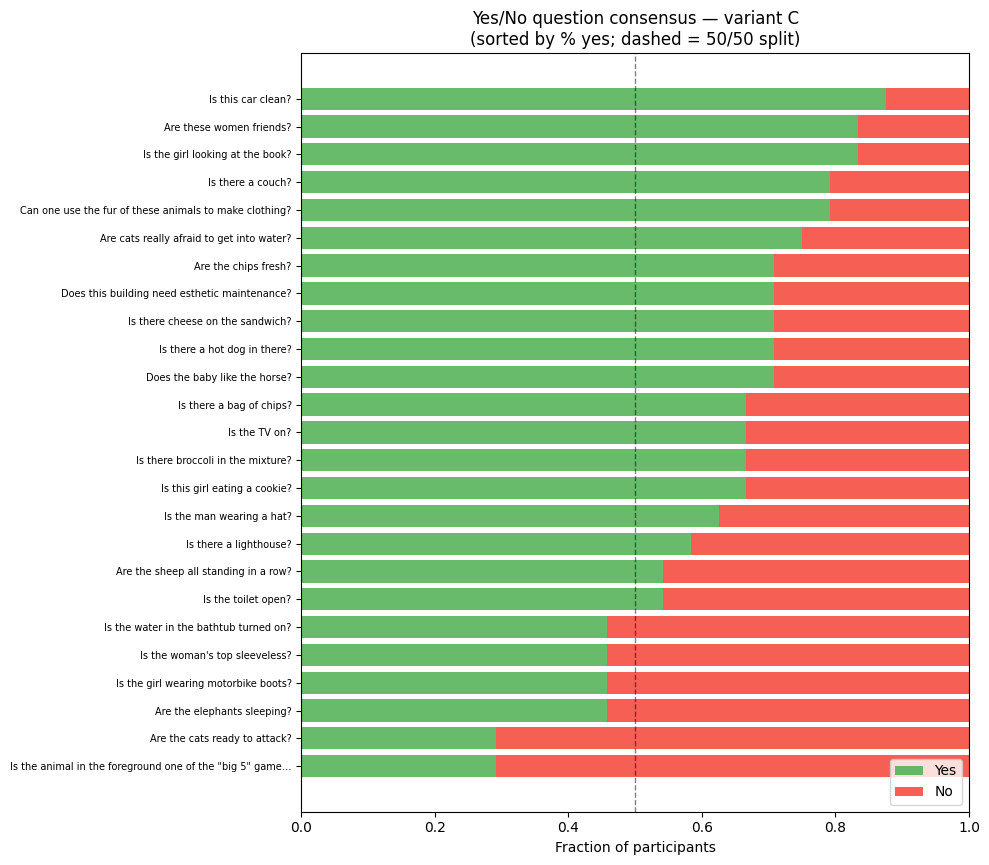


Strong consensus (≥80%/≤20%): 3/25 questions
Close split (40–60%):           7/25 questions
                                                        question  yes_frac  n
Is the animal in the foreground one of the "big 5" game animals?  0.291667 24
                                   Are the cats ready to attack?  0.291667 24
                                     Are the elephants sleeping?  0.458333 24
                            Is the girl wearing motorbike boots?  0.458333 24
                                  Is the woman's top sleeveless?  0.458333 24
                          Is the water in the bathtub turned on?  0.458333 24
                                             Is the toilet open?  0.541667 24
                            Are the sheep all standing in a row?  0.541667 24
                                          Is there a lighthouse?  0.583333 24
                                       Is the man wearing a hat?  0.625000 24
                                   Is this girl e

In [36]:
# ── Yes/No consensus matrix (variant C) ──────────────────────────────────────
import re as _re
_yn_norm = lambda s: 'yes' if _re.sub(r'[^\w]','',str(s).lower().strip()) in ('yes','y')                      else ('no' if _re.sub(r'[^\w]','',str(s).lower().strip()) in ('no','n') else None)

yn_df = df[(df['question_id'].isin(yesno_qids)) & (df['variant'] == 'C')].copy()
yn_df['yn'] = yn_df['answer_en'].map(_yn_norm)
yn_df = yn_df.dropna(subset=['yn'])

# Per-question yes fraction
q_yes_frac = yn_df.groupby('question_id').apply(
    lambda g: (g['yn'] == 'yes').sum() / len(g)
).rename('yes_frac').reset_index()

# Join question text
q_txt = {e['question_id']: e['question_en']
         for e in json.load(open(BASE / 'experiment/s2_v4/s4_question.json'))}
q_yes_frac['question'] = q_yes_frac['question_id'].map(q_txt)
q_yes_frac['n'] = yn_df.groupby('question_id').size().values
q_yes_frac = q_yes_frac.sort_values('yes_frac').reset_index(drop=True)

# ── Plot: horizontal stacked bar (yes% / no%) sorted by yes_frac ─────────────
fig, ax = plt.subplots(figsize=(10, max(6, len(q_yes_frac) * 0.35)))
ys = range(len(q_yes_frac))
ax.barh(ys, q_yes_frac['yes_frac'],         color='#4CAF50', alpha=0.85, label='Yes')
ax.barh(ys, 1 - q_yes_frac['yes_frac'], left=q_yes_frac['yes_frac'],
        color='#F44336', alpha=0.85, label='No')
ax.axvline(0.5, color='black', lw=1, ls='--', alpha=0.5)
ax.set_yticks(list(ys))
ax.set_yticklabels([f"{r['question'][:55]}…" if len(r['question'])>55 else r['question']
                    for _, r in q_yes_frac.iterrows()], fontsize=7)
ax.set_xlabel('Fraction of participants')
ax.set_title('Yes/No question consensus — variant C\n(sorted by % yes; dashed = 50/50 split)')
ax.legend(loc='lower right')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

# Summary stats
consensus = ((q_yes_frac['yes_frac'] >= 0.8) | (q_yes_frac['yes_frac'] <= 0.2)).sum()
split = ((q_yes_frac['yes_frac'] > 0.4) & (q_yes_frac['yes_frac'] < 0.6)).sum()
print(f'\nStrong consensus (≥80%/≤20%): {consensus}/{len(q_yes_frac)} questions')
print(f'Close split (40–60%):           {split}/{len(q_yes_frac)} questions')
print(q_yes_frac[['question','yes_frac','n']].to_string(index=False))


In [ ]:
# ── Agreement by variant — box plots ─────────────────────────────────────────
# n per question = number of participants answering that question in variant C
# Agreement score = mean pairwise [metric] over all C(n,2) pairs of participants
# Box shows distribution across all common questions (text+yesno combined)

per_q_n = df[df['variant'] == 'C'].groupby('question_id')['answer_en'].count()
n_min, n_max, n_med = int(per_q_n.min()), int(per_q_n.max()), int(per_q_n.median())

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
methods = [('exact', 'Exact match'), ('jaccard', 'Token Jaccard'), ('sbert', 'SBERT cosine')]
colors  = {'C': '#2196F3', 'B': '#FF9800', 'A': '#E91E63'}

for ax, (meth, title) in zip(axes, methods):
    data = [agree[var][meth].dropna().values for var in VARIANT_ORDER]
    ns   = [len(d) for d in data]
    bp = ax.boxplot(data, labels=[VARIANT_LABELS[v] for v in VARIANT_ORDER],
                    patch_artist=True, medianprops=dict(color='black', lw=2))
    for patch, var in zip(bp['boxes'], VARIANT_ORDER):
        patch.set_facecolor(colors[var])
        patch.set_alpha(0.7)
    ax.set_title(title)
    ax.set_ylabel('Agreement score')
    ax.tick_params(axis='x', rotation=10)
    # Annotate n questions per variant
    for i, (var, n_q) in enumerate(zip(VARIANT_ORDER, ns), 1):
        ax.text(i, ax.get_ylim()[0], f'n={n_q}q', ha='center', va='bottom',
                fontsize=7, color='#555')

n_participants = df['participant_id'].nunique()
plt.suptitle(
    f'Inter-participant agreement by variant\n'
    f'({n_participants} participants, {n_min}–{n_max} per question, median={n_med}; '
    f'agreement = mean pairwise score over C(n,2) pairs)',
    y=1.04, fontsize=9
)
plt.tight_layout()
plt.show()

Pearson r — SBERT agreement vs human accuracy:
  Variant C: r=0.703  p=0.000  n=113
  Variant B: r=0.680  p=0.000  n=113
  Variant A: r=0.741  p=0.000  n=113


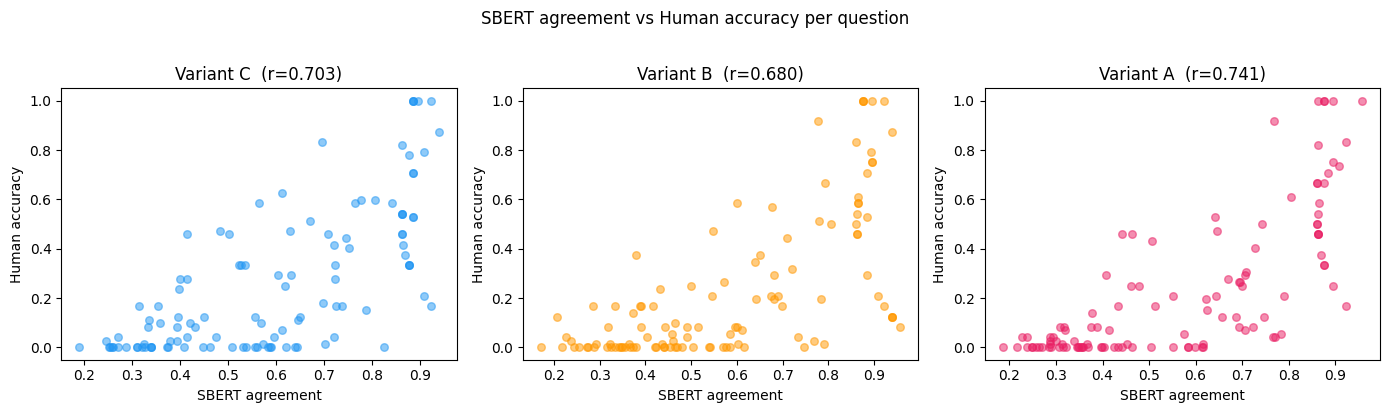

In [38]:
# ── Correlation: agreement vs human accuracy ──────────────────────────────────
# h_acc(q) = mean human accuracy per question per variant
h_acc = df.groupby(['question_id', 'variant'])['accuracy'].mean().unstack()[VARIANT_ORDER]

print('Pearson r — SBERT agreement vs human accuracy:')
for var in VARIANT_ORDER:
    merged = agree[var][['sbert']].join(h_acc[[var]].rename(columns={var: 'acc'})).dropna()
    r, p = pearsonr(merged['sbert'], merged['acc'])
    print(f'  Variant {var}: r={r:.3f}  p={p:.3f}  n={len(merged)}')

# Scatter for variant C
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, var in zip(axes, VARIANT_ORDER):
    merged = agree[var][['sbert', 'exact', 'jaccard']].join(
        h_acc[[var]].rename(columns={var: 'acc'})).dropna()
    ax.scatter(merged['sbert'], merged['acc'], alpha=0.5, color=colors[var], s=30)
    r, _ = pearsonr(merged['sbert'], merged['acc'])
    ax.set_xlabel('SBERT agreement')
    ax.set_ylabel('Human accuracy')
    ax.set_title(f'Variant {var}  (r={r:.3f})')

plt.suptitle('SBERT agreement vs Human accuracy per question', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── Correlation: agreement vs human accuracy — by answer type ─────────────────
# n shown per scatter point = questions; participants per question shown in title
h_acc = df.groupby(['question_id', 'variant'])['accuracy'].mean().unstack()[VARIANT_ORDER]

print('Pearson r — SBERT agreement vs human accuracy:')
for label, ag_dict, qids, avail_metrics in [
        ('All',   agree,    common_qids, ['sbert']),
        ('Yesno', agree_yn, yesno_qids,  ['exact']),   # no SBERT for yesno
        ('Text',  agree_tx, text_qids,   ['sbert'])]:
    print(f'  [{label}]  metric={"sbert" if "sbert" in avail_metrics else "exact (SBERT N/A)"}')
    metric = avail_metrics[0]
    for var in VARIANT_ORDER:
        merged = ag_dict[var][[metric]].join(h_acc[[var]].rename(columns={var:'acc'})).dropna()
        if len(merged) < 3:
            print(f'    Variant {var}: n={len(merged)} (too few)')
            continue
        r, p = pearsonr(merged[metric], merged['acc'])
        print(f'    Variant {var}: r={r:.3f}  p={p:.3f}  n={len(merged)} questions')

# ── Scatter variant C: All / Yesno (exact) / Text (sbert) ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_cfg = [
    ('All questions',  agree,    'sbert', '#607D8B'),
    ('Yes/No (exact)', agree_yn, 'exact', '#4CAF50'),
    ('Free-text (SBERT)', agree_tx, 'sbert', '#FF5722'),
]
for ax, (label, ag_dict, metric, color) in zip(axes, plot_cfg):
    merged = ag_dict['C'][[metric]].join(h_acc[['C']].rename(columns={'C':'acc'})).dropna()
    n_q = len(merged)
    ax.scatter(merged[metric], merged['acc'], alpha=0.6, color=color, s=35)
    if n_q >= 3:
        r, _ = pearsonr(merged[metric], merged['acc'])
        ax.set_title(f'{label}\nr={r:.3f}, n={n_q} questions')
    ax.set_xlabel(f'{metric.upper()} agreement')
    ax.set_ylabel('Human accuracy')

n_participants = df['participant_id'].nunique()
plt.suptitle(
    f'Agreement vs Human accuracy — variant C\n'
    f'({n_participants} participants; agreement = mean pairwise score over C(n,2) pairs)',
    y=1.05, fontsize=9
)
plt.tight_layout()
plt.show()

Agreement by entity type (variant C, sorted by SBERT):
         sbert  exact  jaccard   N
ent                               
food     0.647  0.274    0.289  16
animal   0.619  0.248    0.263  17
object   0.610  0.211    0.221  27
place    0.598  0.270    0.275   5
person   0.572  0.226    0.237  26
other    0.558  0.176    0.188   9
product  0.552  0.140    0.146   5
vehicle  0.541  0.275    0.291   4
text     0.480  0.086    0.087   4


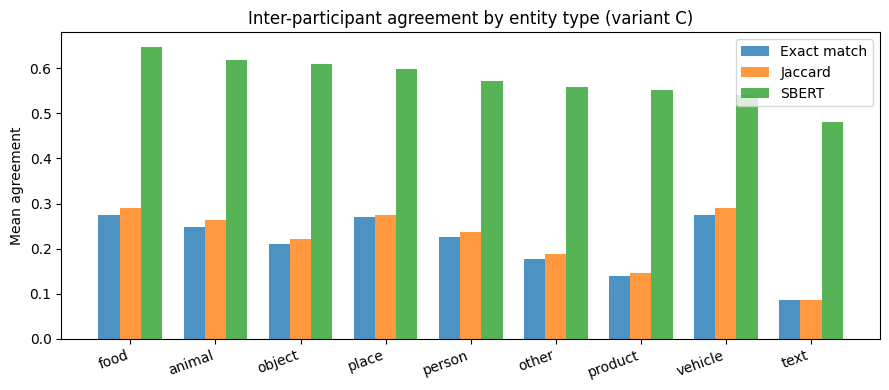

In [40]:
# ── Agreement by entity type ──────────────────────────────────────────────────
ent_map = df[['question_id', 'ent']].drop_duplicates().set_index('question_id')['ent']

ent_agree = agree['C'][['sbert', 'exact', 'jaccard']].join(ent_map).groupby('ent').mean()
ent_n     = agree['C'][['sbert']].join(ent_map).groupby('ent')['sbert'].count().rename('N')
ent_table = ent_agree.join(ent_n).sort_values('sbert', ascending=False)

print('Agreement by entity type (variant C, sorted by SBERT):')
print(ent_table.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(ent_table))
w = 0.25
ax.bar(x - w, ent_table['exact'],   w, label='Exact match', alpha=0.8)
ax.bar(x,     ent_table['jaccard'], w, label='Jaccard',     alpha=0.8)
ax.bar(x + w, ent_table['sbert'],   w, label='SBERT',       alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(ent_table.index, rotation=20, ha='right')
ax.set_ylabel('Mean agreement')
ax.set_title('Inter-participant agreement by entity type (variant C)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Top / bottom agreed FREE-TEXT questions (SBERT, variant C) ────────────────
# n = number of participants per question who answered in variant C
# agreement = mean pairwise SBERT cosine over all C(n,2) pairs

q_en_map = {}
for _, row in df[df['variant'] == 'C'].drop_duplicates('question_id').iterrows():
    q_en_map[row['question_id']] = row.get('question_en', str(row['question_id']))

N = 8
tx_sbert = agree_tx['C']['sbert'].dropna()

for label, ascending in [('LOWEST agreement', True), ('HIGHEST agreement', False)]:
    top = tx_sbert.sort_values(ascending=ascending).head(N)
    print(f'\n── {label} — free-text only (SBERT, variant C) ──')
    for qid, score in top.items():
        answers = df[(df.question_id == qid) & (df.variant == 'C')]['answer_en'].dropna().tolist()
        n = len(answers)
        unique  = sorted(set(answers))
        print(f'  [{score:.3f}, n={n} participants, {len(unique)} unique] {q_en_map.get(qid, qid)}')
        print(f'    answers: {unique[:6]}')

In [ ]:
# ── Top / bottom agreed YES/NO questions (exact match, variant C) ────────────
# For yes/no questions, SBERT is excluded (trivial token embeddings).
# Agreement = fraction of all C(n,2) participant pairs with identical answers.
# Sorted from least agreed (most split) → most agreed (strong consensus).

yn_sbert_excluded_note = '(SBERT excluded — binary token embeddings are uninformative)'

yn_exact = agree_yn['C']['exact'].dropna()
N = 8

for label, ascending in [('MOST SPLIT (lowest exact-match agreement)', True),
                          ('MOST CONSENSUS (highest exact-match agreement)', False)]:
    top = yn_exact.sort_values(ascending=ascending).head(N)
    print(f'\n── {label} — yes/no only (variant C) {yn_sbert_excluded_note} ──')
    for qid, score in top.items():
        answers = df[(df.question_id == qid) & (df.variant == 'C')]['answer_en'].dropna().tolist()
        n = len(answers)
        yn_answers = [_yn_norm(a) for a in answers]
        yes_n = yn_answers.count('yes')
        no_n  = yn_answers.count('no')
        other = n - yes_n - no_n
        other_str = f', {other} other' if other else ''
        print(f'  [exact={score:.3f}, n={n}] {q_en_map.get(qid, qid)}')
        print(f'    yes={yes_n}, no={no_n}{other_str}')